### 3.2 Task - 1: Implementation of MCP Neurons:

### For ”AND” Operations.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operation using MCP Neuron.

    Arguments:
    X1: list or array of binary values (0 or 1)
    X2: list or array of binary values (0 or 1)
    T : threshold value

    Returns:
    state_neuron: list containing output (0 or 1)
    """

    # Make sure both inputs are of same length
    assert len(X1) == len(X2)

    # This will store the final outputs (0 or 1)
    state_neuron = []

    # Loop through both input arrays together
    for i in range(len(X1)):

        # Step 1: Add corresponding elements
        summation = X1[i] + X2[i]

        # Step 2: Apply threshold (this is the "brain" decision)
        # If sum >= threshold → neuron fires (1)
        # Else → neuron does not fire (0)
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


### For ”OR” Operations.

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operation using MCP Neuron.

    Arguments:
    X1: list or array of binary values (0 or 1)
    X2: list or array of binary values (0 or 1)
    T : threshold value

    Returns:
    state_neuron: list containing output (0 or 1)
    """

    # Make sure both inputs have same number of elements
    assert len(X1) == len(X2)

    # This list will store the final outputs
    state_neuron = []

    # Loop through inputs one by one
    for i in range(len(X1)):

        # Step 1: Add both inputs
        summation = X1[i] + X2[i]

        # Step 2: Apply threshold rule
        # For OR → if at least one input is 1, output should be 1
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### For ”OR” Operations.

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operation using MCP Neuron.

    Arguments:
    X1 (1D array): binary inputs (0 or 1)
    X2 (1D array): binary inputs (0 or 1)
    T  : threshold value

    Returns:
    state_neuron (list): output values (0 or 1)
    """

    # Make sure both inputs are same length
    assert len(X1) == len(X2)

    # This will store the outputs
    state_neuron = []

    # Go through each pair of inputs
    for i in range(len(X1)):

        # Add corresponding elements
        summation = X1[i] + X2[i]

        # Apply threshold rule
        # For OR → if sum is at least 1, output should be 1
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### 3.2.1 Answer the Following Question:

### Question - 1: List out all the limitations of MCP - Neurons.
### 1. MCP neurons can only solve linearly separable problems (cannot solve XOR).
### 2. They do not have a learning mechanism (weights are fixed).
### 3. They only accept binary inputs (0 and 1).
### 4. They use a hard threshold function (output is only 0 or 1).
### 5. They are limited to simple tasks and cannot handle complex real-world problems.

### Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
### A single MCP neuron cannot solve XOR because it can only handle simple patterns, and XOR is not one of them. The outputs are mixed in a way that one straight line can’t separate them. But if we use multiple MCP neurons together (like combining AND, OR, and NOT), then XOR can be solved.

## Task 2: Perceptron Algorithm for 0 vs 1 Classification.

### Load the Dataset:

In [ ]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI GOOGLE COLAB Y2S1/Copy of mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


## Initialization of the Weights:

In [ ]:
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Implementation Decision Function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """

    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

### Training the Perceptron:

In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    # Step 3: Perceptron Learning Algorithm
    for _ in range(epochs):
        for i in range(len(X)):

            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation function
            y_pred = 1 if linear_output >= 0 else 0

            # Update weights and bias
            weights = weights + learning_rate * (y[i] - y_pred) * X[i]
            bias = bias + learning_rate * (y[i] - y_pred)

    # Calculate accuracy
    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(predictions == y)

    return weights, bias, accuracy

## Training the Perceptron Algorithm:

### 1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 3 and 5. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_3_and_5.csv

### To - Do:
###1. Implement each Step as we implemente above.

### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI GOOGLE COLAB Y2S1/mnist_3_and_5.csv")

print(df.shape)
df.head()

(2741, 785)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Prepare Features and Labels

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

### Convert Labels to Binary (-1 and +1)

In [ ]:
y = np.where(y == 5, 1, -1)

### Normalize Data (Important for Perceptron)

In [ ]:
X = X / 255.0

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Perceptron Implementation

In [ ]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else -1

                if y[i] != y_pred:
                    self.weights += self.lr * y[i] * X[i]
                    self.bias += self.lr * y[i]

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

### Train Model

In [ ]:
model = Perceptron(lr=0.01, epochs=20)
model.fit(X_train, y_train)

### Evaluate Accuracy

In [ ]:
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9326047358834244


### Visualize Misclassified Images

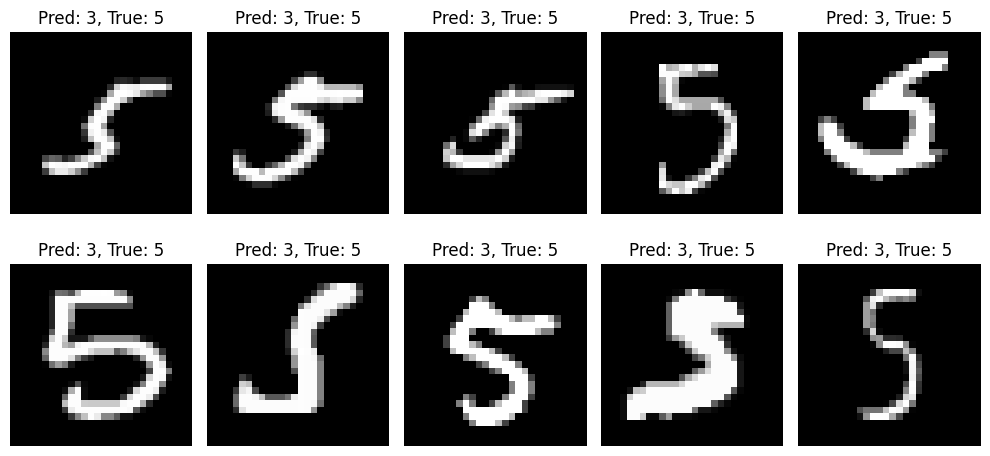

In [ ]:
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,5))

for i, index in enumerate(misclassified[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')

    pred = 5 if y_pred[index] == 1 else 3
    true = 5 if y_test[index] == 1 else 3

    plt.title(f"Pred: {pred}, True: {true}")
    plt.axis('off')

plt.tight_layout()
plt.show()